### [Backtesting Trading Strategies the Right Way](https://wire.insiderfinance.io/backtesting-trading-strategies-the-right-way-avoid-these-mistakes-3db40f13de48)

> Backtesting is the process of testing a trading strategy using historical market data.

The goal is to determine whether a strategy would have been profitable in the past.

A proper backtest evaluates:

- profitability
- risk exposure
- drawdowns
- win rate
- consistency across market conditions

If a strategy performs well across historical data, it may have potential to work in the future.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

In [2]:
data = yf.download("SPY", period="5y", progress=False)

if isinstance(data.columns, pd.MultiIndex):
  data.columns = data.columns.get_level_values(0)

display(data.head(10))

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-03-15,370.039337,370.300709,365.950706,368.097691,73427200
2021-03-16,369.572601,371.364860,368.797800,370.655437,73722500
2021-03-17,370.832764,371.635540,367.136177,368.284363,97959300
2021-03-18,365.437286,370.328693,364.755838,368.237715,115349100
2021-03-19,364.761139,366.718491,362.578999,365.135747,113624500
2021-03-22,367.673828,369.059909,365.220114,365.276304,73778600
2021-03-23,364.779877,368.488542,363.993192,367.036926,90686600
2021-03-24,362.925507,367.823588,362.878691,366.184654,97588600
2021-03-25,364.967224,365.763255,359.535311,361.483317,116128600


In [3]:
data["SMA50"] = data["Close"].rolling(50).mean()
data["SMA200"] = data["Close"].rolling(200).mean()

display(data.head(10))

Price,Close,High,Low,Open,Volume,SMA50,SMA200
Date,,,,,,,
2021-03-15,370.039337,370.300709,365.950706,368.097691,73427200,NaN,NaN
2021-03-16,369.572601,371.364860,368.797800,370.655437,73722500,NaN,NaN
2021-03-17,370.832764,371.635540,367.136177,368.284363,97959300,NaN,NaN
2021-03-18,365.437286,370.328693,364.755838,368.237715,115349100,NaN,NaN
2021-03-19,364.761139,366.718491,362.578999,365.135747,113624500,NaN,NaN
2021-03-22,367.673828,369.059909,365.220114,365.276304,73778600,NaN,NaN
2021-03-23,364.779877,368.488542,363.993192,367.036926,90686600,NaN,NaN
2021-03-24,362.925507,367.823588,362.878691,366.184654,97588600,NaN,NaN
2021-03-25,364.967224,365.763255,359.535311,361.483317,116128600,NaN,NaN


In [4]:
data["Signal"] = 0
data.loc[data["SMA50"] > data["SMA200"], "Signal"] = 1
data.loc[data["SMA50"] < data["SMA200"], "Signal"] = -1

display(data.head(10))

Price,Close,High,Low,Open,Volume,SMA50,SMA200,Signal
Date,,,,,,,,
2021-03-15,370.039337,370.300709,365.950706,368.097691,73427200,NaN,NaN,0
2021-03-16,369.572601,371.364860,368.797800,370.655437,73722500,NaN,NaN,0
2021-03-17,370.832764,371.635540,367.136177,368.284363,97959300,NaN,NaN,0
2021-03-18,365.437286,370.328693,364.755838,368.237715,115349100,NaN,NaN,0
2021-03-19,364.761139,366.718491,362.578999,365.135747,113624500,NaN,NaN,0
2021-03-22,367.673828,369.059909,365.220114,365.276304,73778600,NaN,NaN,0
2021-03-23,364.779877,368.488542,363.993192,367.036926,90686600,NaN,NaN,0
2021-03-24,362.925507,367.823588,362.878691,366.184654,97588600,NaN,NaN,0
2021-03-25,364.967224,365.763255,359.535311,361.483317,116128600,NaN,NaN,0


In [5]:
data["Returns"] = data["Close"].pct_change()
data["Strategy"] = data["Returns"] * data["Signal"].shift()

display(data.head(10))

Price,Close,High,Low,Open,Volume,SMA50,SMA200,Signal,Returns,Strategy
Date,,,,,,,,,,
2021-03-15,370.039337,370.300709,365.950706,368.097691,73427200,NaN,NaN,0,NaN,NaN
2021-03-16,369.572601,371.364860,368.797800,370.655437,73722500,NaN,NaN,0,-0.001261,-0.0
2021-03-17,370.832764,371.635540,367.136177,368.284363,97959300,NaN,NaN,0,0.003410,0.0
2021-03-18,365.437286,370.328693,364.755838,368.237715,115349100,NaN,NaN,0,-0.014550,-0.0
2021-03-19,364.761139,366.718491,362.578999,365.135747,113624500,NaN,NaN,0,-0.001850,-0.0
2021-03-22,367.673828,369.059909,365.220114,365.276304,73778600,NaN,NaN,0,0.007985,0.0
2021-03-23,364.779877,368.488542,363.993192,367.036926,90686600,NaN,NaN,0,-0.007871,-0.0
2021-03-24,362.925507,367.823588,362.878691,366.184654,97588600,NaN,NaN,0,-0.005084,-0.0
2021-03-25,364.967224,365.763255,359.535311,361.483317,116128600,NaN,NaN,0,0.005626,0.0


<Axes: xlabel='Date'>

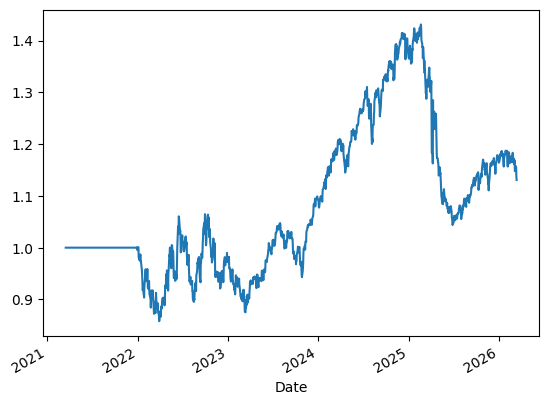

In [6]:
equity_curve = (1 + data["Strategy"]).cumprod()
equity_curve.plot()